In [67]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

from scipy.stats import skew, kurtosis

In [3]:
students = pd.read_csv("C:/Users/Home/Desktop/FYP/EduMate-AI/data/student.csv")

In [4]:
students

,student_id,name,email,course,learning_style,communication,personality,gpa
0,S0001,Hassan Qureshi,hassan.qureshi68@student.edu.pk,Data Science,Kinesthetic,Average,Ambivert,2.84
1,S0002,Usman Rana,usman.rana681@student.edu.pk,Artificial Intelligence,Auditory,Strong,Introvert,2.17
2,S0003,Ahmad Iftikhar,ahmad.iftikhar869@student.edu.pk,Cyber Security,Reading/Writing,Average,Introvert,2.59
3,S0004,Hassan Iftikhar,hassan.iftikhar936@student.edu.pk,Information Technology,Reading/Writing,Weak,Extrovert,3.44
4,S0005,Sana Butt,sana.butt327@student.edu.pk,Software Engineering,Reading/Writing,Strong,Introvert,2.85
...,...,...,...,...,...,...,...,...
495,S0496,Fatima Ashraf,fatima.ashraf990@student.edu.pk,Data Science,Auditory,Strong,Introvert,3.99
496,S0497,Bilal Qureshi,bilal.qureshi373@student.edu.pk,Software Engineering,Kinesthetic,Strong,Ambivert,3.07
497,S0498,Jawad Ashraf,jawad.ashraf313@student.edu.pk,Information Technology,Visual,Weak,Extrovert,2.16
498,S0499,Fatima Qureshi,fatima.qureshi681@student.edu.pk,Cyber Security,Visual,Strong,Extrovert,2.99


In [5]:
students.columns

Index(['student_id', 'name', 'email', 'course', 'learning_style',
       'communication', 'personality', 'gpa'],
      dtype='object')

In [6]:
students.shape

(500, 8)

In [7]:
students.sample(10)

,student_id,name,email,course,learning_style,communication,personality,gpa
323,S0324,Bilal Rana,bilal.rana887@student.edu.pk,Machine Learning,Reading/Writing,Weak,Extrovert,3.00
208,S0209,Ali Butt,ali.butt222@student.edu.pk,Machine Learning,Reading/Writing,Weak,Ambivert,3.19
421,S0422,Ahmad Siddiqui,ahmad.siddiqui735@student.edu.pk,Computer Networks,Visual,Strong,Ambivert,3.04
27,S0028,Jawad Khan,jawad.khan440@student.edu.pk,Artificial Intelligence,Reading/Writing,Average,Extrovert,2.72
372,S0373,Maryam Chaudhry,maryam.chaudhry268@student.edu.pk,Artificial Intelligence,Kinesthetic,Strong,Introvert,3.47
440,S0441,Usman Qureshi,usman.qureshi11@student.edu.pk,Machine Learning,Reading/Writing,Strong,Extrovert,3.17
380,S0381,Muneeb Sheikh,muneeb.sheikh533@student.edu.pk,Software Engineering,Reading/Writing,Weak,Extrovert,3.05
99,S0100,Usman Rana,usman.rana153@student.edu.pk,Information Technology,Reading/Writing,Strong,Extrovert,2.72
124,S0125,Maryam Qureshi,maryam.qureshi961@student.edu.pk,Cloud Computing,Reading/Writing,Weak,Introvert,3.57
160,S0161,Sana Siddiqui,sana.siddiqui415@student.edu.pk,Computer Networks,Auditory,Average,Introvert,2.84


In [8]:
students.nunique()

student_id        500
name              137
email             499
course              9
learning_style      4
communication       3
personality         3
gpa               186
dtype: int64

In [9]:
students.drop(columns = ['email'], inplace = True)

In [10]:
students.shape

(500, 7)

In [11]:
students.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      500 non-null    object 
 1   name            500 non-null    object 
 2   course          500 non-null    object 
 3   learning_style  500 non-null    object 
 4   communication   500 non-null    object 
 5   personality     500 non-null    object 
 6   gpa             500 non-null    float64
dtypes: float64(1), object(6)
memory usage: 27.5+ KB


In [13]:
students.dtypes

student_id         object
name               object
course             object
learning_style     object
communication      object
personality        object
gpa               float64
dtype: object

In [32]:
print(f"<========== HANDLING MISSING VALUES ==========>")
print("")
print(f"Missing Values:")
print(f"{students.isnull().sum()}")

<========== HANDLING MISSING VALUES ==========>

Missing Values:
student_id        0
name              0
course            0
learning_style    0
communication     0
personality       0
gpa               0
dtype: int64


In [28]:
print(f"<========== DUPLICATE ROWS ==========>")
print("")
print(f"Duplicate Rows are: {students.duplicated().sum()}")

<========== DUPLICATE ROWS ==========>

Duplicate Rows are: 0


In [18]:
students.corr(method='pearson', numeric_only=True)

,gpa
gpa,1.0


In [16]:
students.head()

,student_id,name,course,learning_style,communication,personality,gpa
0,S0001,Hassan Qureshi,Data Science,Kinesthetic,Average,Ambivert,2.84
1,S0002,Usman Rana,Artificial Intelligence,Auditory,Strong,Introvert,2.17
2,S0003,Ahmad Iftikhar,Cyber Security,Reading/Writing,Average,Introvert,2.59
3,S0004,Hassan Iftikhar,Information Technology,Reading/Writing,Weak,Extrovert,3.44
4,S0005,Sana Butt,Software Engineering,Reading/Writing,Strong,Introvert,2.85


In [41]:
students.head()

,student_id,name,course,learning_style,communication,personality,gpa
0,S0001,Hassan Qureshi,Data Science,Kinesthetic,Average,ambivert,2.84
1,S0002,Usman Rana,Artificial Intelligence,Auditory,Strong,introvert,2.17
2,S0003,Ahmad Iftikhar,Cyber Security,Reading/Writing,Average,introvert,2.59
3,S0004,Hassan Iftikhar,Information Technology,Reading/Writing,Weak,extrovert,3.44
4,S0005,Sana Butt,Software Engineering,Reading/Writing,Strong,introvert,2.85


In [55]:
# Clean and standardize text columns
text_columns = ['name', 'course', 'learning_style', 'communication', 'personality']
for col in text_columns:
    if col in students.columns:
        students[col] = students[col].str.strip().str.lower()

In [47]:
students.describe(include='all')

,student_id,name,course,learning_style,communication,personality,gpa
count,500,500,500,500,500,500,500.000000
unique,500,137,9,4,3,3,NaN
top,s0500,hiba ashraf,deep learning,reading/writing,weak,extrovert,NaN
freq,1,9,68,136,177,173,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,3.000700
std,NaN,NaN,NaN,NaN,NaN,NaN,0.561254
min,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2.537500
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.990000
75%,NaN,NaN,NaN,NaN,NaN,NaN,3.470000


In [48]:
print('<========== VALUE COUNTS OF STUDENT_ID COLUMN ==========>') 
print('')
print('student_id shape:', students[['student_id']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['student_id']].value_counts())

<========== VALUE COUNTS OF STUDENT_ID COLUMN ==========>

student_id shape: (500,)

Frequency Counts:
 student_id
s0500         1
s0001         1
s0002         1
s0003         1
s0484         1
             ..
s0009         1
s0008         1
s0007         1
s0006         1
s0005         1
Name: count, Length: 500, dtype: int64


In [49]:
print('<========== VALUE COUNTS OF NAME COLUMN ==========>') 
print('')
print('name shape:', students[['name']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['name']].value_counts())

<========== VALUE COUNTS OF NAME COLUMN ==========>

name shape: (137,)

Frequency Counts:
 name         
hiba ashraf      9
jawad rana       8
jawad malik      8
bilal malik      8
sana chaudhry    8
                ..
hamza sheikh     1
hiba rana        1
usman butt       1
zara malik       1
zara khan        1
Name: count, Length: 137, dtype: int64


In [50]:
print('<========== VALUE COUNTS OF COURSE COLUMN ==========>') 
print('')
print('course shape:', students[['course']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['course']].value_counts())

<========== VALUE COUNTS OF COURSE COLUMN ==========>

course shape: (9,)

Frequency Counts:
 course                 
deep learning              68
machine learning           64
information technology     64
data science               58
artificial intelligence    55
computer networks          55
software engineering       47
cloud computing            46
cyber security             43
Name: count, dtype: int64


In [51]:
print('<========== VALUE COUNTS OF LEARNING STYLE COLUMN ==========>') 
print('')
print('learning _style shape:', students[['learning_style']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['learning_style']].value_counts())

<========== VALUE COUNTS OF LEARNING STYLE COLUMN ==========>

learning _style shape: (4,)

Frequency Counts:
 learning_style 
reading/writing    136
auditory           127
visual             119
kinesthetic        118
Name: count, dtype: int64


In [52]:
print('<========== VALUE COUNTS OF COMMUNICATION COLUMN ==========>') 
print('')
print('communication shape:', students[['communication']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['communication']].value_counts())

<========== VALUE COUNTS OF COMMUNICATION COLUMN ==========>

communication shape: (3,)

Frequency Counts:
 communication
weak             177
strong           172
average          151
Name: count, dtype: int64


In [53]:
print('<========== VALUE COUNTS OF PERSONALITY COLUMN ==========>') 
print('')
print('personality shape:', students[['personality']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['personality']].value_counts())

<========== VALUE COUNTS OF PERSONALITY COLUMN ==========>

personality shape: (3,)

Frequency Counts:
 personality
extrovert      173
introvert      165
ambivert       162
Name: count, dtype: int64


In [54]:
print('<========== VALUE COUNTS OF GPA COLUMN ==========>') 
print('')
print('GPA shape:', students[['gpa']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['gpa']].value_counts())

<========== VALUE COUNTS OF GPA COLUMN ==========>

GPA shape: (186,)

Frequency Counts:
 gpa 
3.33    7
2.95    7
2.98    6
3.71    6
2.59    6
       ..
3.85    1
3.90    1
3.89    1
3.92    1
3.98    1
Name: count, Length: 186, dtype: int64


In [30]:
students.sample(5)

,student_id,name,course,learning_style,communication,personality,gpa
270,S0271,Hiba Chaudhry,Computer Networks,Reading/Writing,Strong,extrovert,2.02
279,S0280,Fatima Siddiqui,Information Technology,Reading/Writing,Average,ambivert,3.21
93,S0094,Ayesha Malik,Machine Learning,Auditory,Weak,introvert,3.06
246,S0247,Usman Iftikhar,Software Engineering,Auditory,Strong,introvert,2.95
430,S0431,Jawad Rana,Data Science,Reading/Writing,Weak,ambivert,2.58


# **Univariate Analysis**

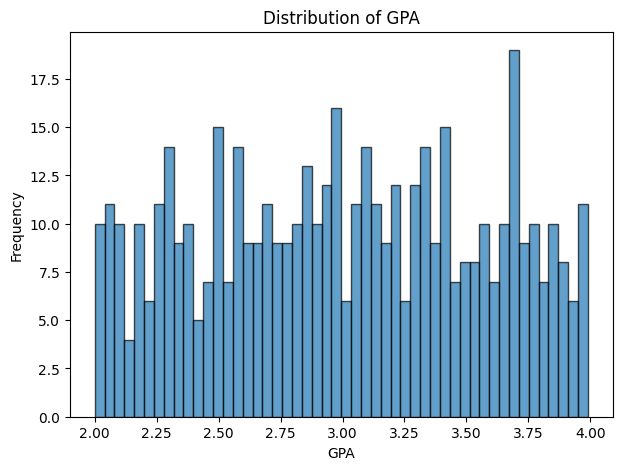

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(students['gpa'], bins = 50, edgecolor = 'black', alpha = 0.7)
plt.title("Distribution of GPA")
plt.xlabel('GPA')
plt.ylabel("Frequency")
plt.show()

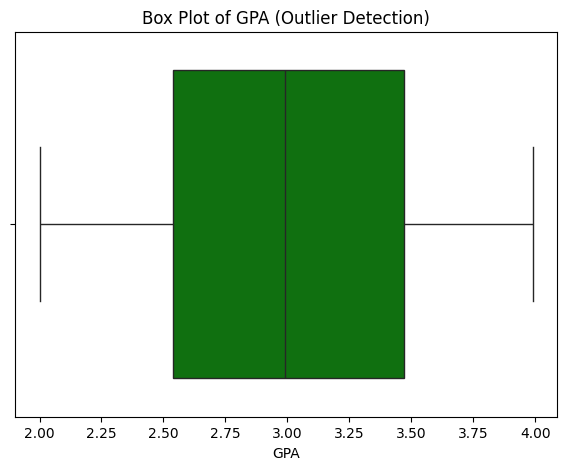

Number of GPA outliers (IQR method): 0
Lower bound: 1.14, Upper bound: 4.87


In [66]:
# Box plot for GPA to check outliers
plt.figure(figsize=(7, 5))
sns.boxplot(x=students['gpa'], color='green')
plt.title("Box Plot of GPA (Outlier Detection)")
plt.xlabel('GPA')
plt.show()

# Identify outliers using IQR method
Q1 = students['gpa'].quantile(0.25)
Q3 = students['gpa'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = students[(students['gpa'] < lower_bound) | (students['gpa'] > upper_bound)]
print(f"Number of GPA outliers (IQR method): {len(outliers)}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
if len(outliers) > 0:
    print(f"Outlier GPA values: {outliers['gpa'].tolist()}")

In [69]:
# Calculate skewness and kurtosis for GPA

gpa_data = students['gpa'].dropna()
gpa_skew = skew(gpa_data)
gpa_kurt = kurtosis(gpa_data)

print("\n" + "="*50)
print("GPA DISTRIBUTION CHARACTERISTICS")
print("="*50)
print(f"Mean GPA: {students['gpa'].mean():.3f}")
print(f"Median GPA: {students['gpa'].median():.3f}")
print(f"Standard Deviation: {students['gpa'].std():.3f}")
print(f"Skewness: {gpa_skew:.3f}")
print(f"Kurtosis: {gpa_kurt:.3f}")

# Interpretation of skewness and kurtosis
print("\n--- Interpretation ---")
if abs(gpa_skew) < 0.5:
    print("• GPA distribution is approximately symmetric")
elif gpa_skew > 0:
    print(f"• GPA distribution is positively skewed (right-skewed)")
    print("  Most students have lower GPAs, few have very high GPAs")
else:
    print(f"• GPA distribution is negatively skewed (left-skewed)")
    print("  Most students have higher GPAs, few have very low GPAs")

if abs(gpa_kurt) < 0.5:
    print("• GPA distribution has normal kurtosis (mesokurtic)")
elif gpa_kurt > 0:
    print(f"• GPA distribution has high kurtosis (leptokurtic)")
    print("  Data has heavier tails and sharper peak than normal")
else:
    print(f"• GPA distribution has low kurtosis (platykurtic)")
    print("  Data has lighter tails and flatter peak than normal")

# Check if data is approximately normal using skewness/kurtosis test
if abs(gpa_skew) < 2 and abs(gpa_kurt) < 2:
    print("• GPA distribution is approximately normal")
else:
    print("• GPA distribution is not normal")


GPA DISTRIBUTION CHARACTERISTICS
Mean GPA: 3.001
Median GPA: 2.990
Standard Deviation: 0.561
Skewness: -0.032
Kurtosis: -1.122

--- Interpretation ---
• GPA distribution is approximately symmetric
• GPA distribution has low kurtosis (platykurtic)
  Data has lighter tails and flatter peak than normal
• GPA distribution is approximately normal


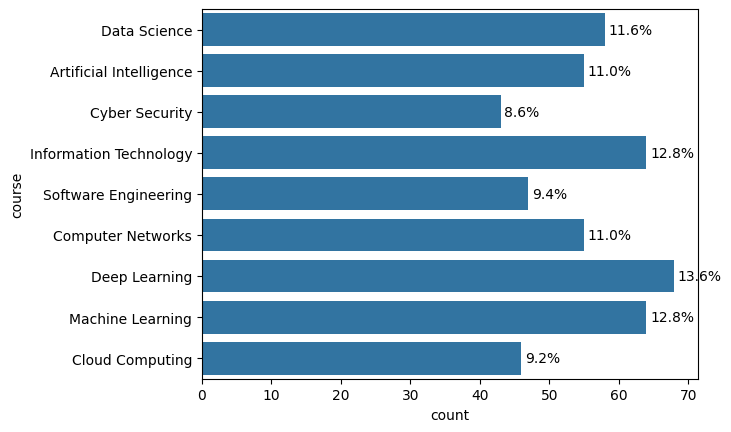

In [32]:
# count plot (i.e. Course Column)
ax = sns.countplot(y='course', data=students)

# Total number of students
total = len(students)

# Add percentage labels along the x-axis
for p in ax.patches:
    count = p.get_width()            # width = count for horizontal bars
    pct = count / total * 100
    ax.text(
        count + 0.5,                 # x-position: slightly after the end of bar
        p.get_y() + p.get_height()/2, # y-position: center of the bar
        f'{pct:.1f}%',               # label
        va='center'                  # vertical alignment
    )

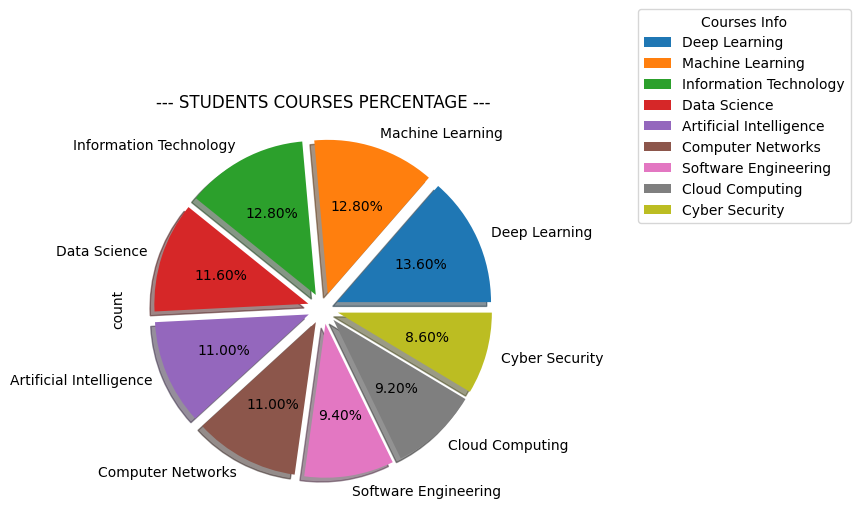

In [34]:
# figure size
plt.figure(figsize = (12, 5)) # Adjust the figure size to visually represent the pie chart 
myexplode = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
# pie chart
students['course'].value_counts().plot(kind = 'pie', autopct = '%.2f%%', explode = myexplode, shadow = True) # plot the pie chart on course column 
# title
plt.title("--- STUDENTS COURSES PERCENTAGE ---")
# legend
plt.legend(loc = 'center left', title = 'Courses Info', bbox_to_anchor = (1.3, 1)) # used to add a list of explanation for each wedge
# show plot
plt.show()

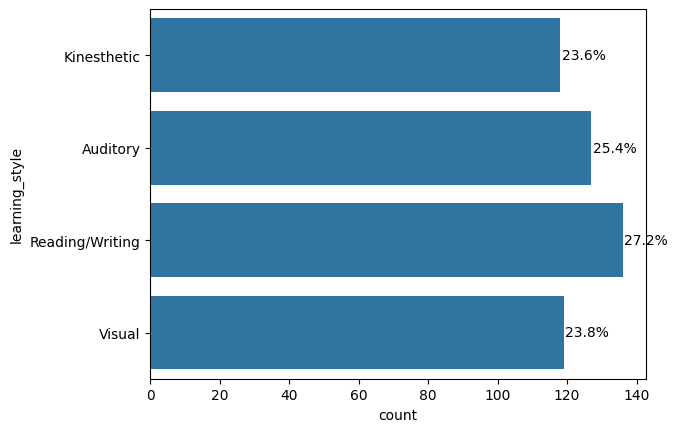

In [35]:
# count plot (i.e. Course Column)
ax = sns.countplot(y='learning_style', data=students)

# Total number of students
total = len(students)

# Add percentage labels along the x-axis
for p in ax.patches:
    count = p.get_width()            # width = count for horizontal bars
    pct = count / total * 100
    ax.text(
        count + 0.5,                 # x-position: slightly after the end of bar
        p.get_y() + p.get_height()/2, # y-position: center of the bar
        f'{pct:.1f}%',               # label
        va='center'                  # vertical alignment
    )

In [74]:
students['learning_style'].value_counts()

learning_style
reading/writing    136
auditory           127
visual             119
kinesthetic        118
Name: count, dtype: int64

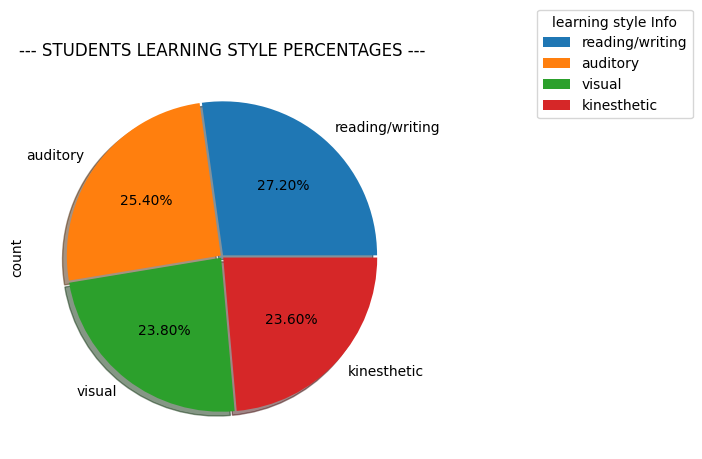

In [77]:
# figure size
plt.figure(figsize = (12, 5)) # Adjust the figure size to visually represent the pie chart 
myexplode = [0.01, 0.01, 0.01, 0.01]
# pie chart
students['learning_style'].value_counts().plot(kind = 'pie', autopct = '%.2f%%', explode = myexplode, shadow = True) # plot the pie chart on course column 
# title
plt.title("--- STUDENTS LEARNING STYLE PERCENTAGES ---")
# legend
plt.legend(loc = 'center left', title = 'learning style Info', bbox_to_anchor = (1.3, 1)) # used to add a list of explanation for each wedge
# show plot
plt.show()

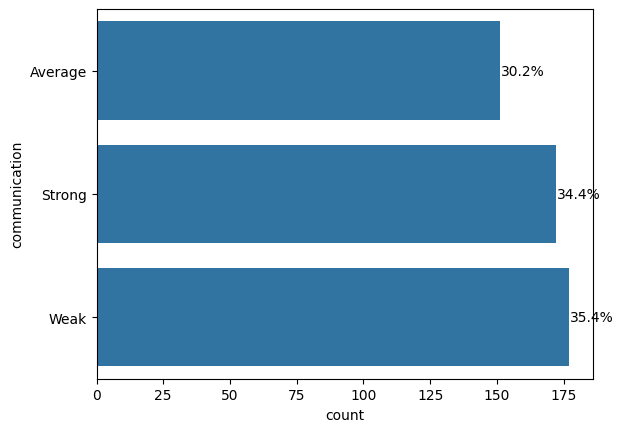

In [37]:
# count plot (i.e. Communication Column)
ax = sns.countplot(y='communication', data=students)

# Total number of students
total = len(students)

# Add percentage labels along the x-axis
for p in ax.patches:
    count = p.get_width()            # width = count for horizontal bars
    pct = count / total * 100
    ax.text(
        count + 0.5,                 # x-position: slightly after the end of bar
        p.get_y() + p.get_height()/2, # y-position: center of the bar
        f'{pct:.1f}%',               # label
        va='center'                  # vertical alignment
    )

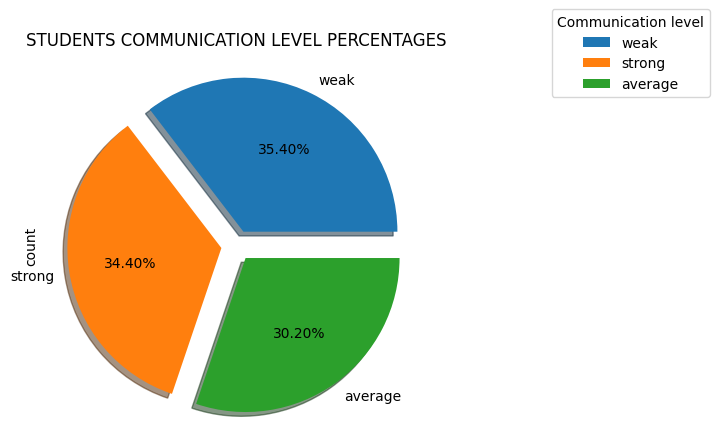

In [80]:
# figure size
plt.figure(figsize = (12, 5)) # Adjust the figure size to visually represent the pie chart 
myexplode = [0.1, 0.1, 0.1]
# pie chart
students['communication'].value_counts().plot(kind = 'pie', autopct = '%.2f%%', explode = myexplode, shadow = True) # plot the pie chart on course column 
# title
plt.title("STUDENTS COMMUNICATION LEVEL PERCENTAGES")
# legend
plt.legend(loc = 'center left', title = 'Communication level', bbox_to_anchor = (1.3, 1)) # used to add a list of explanation for each wedge
# show plot
plt.show()

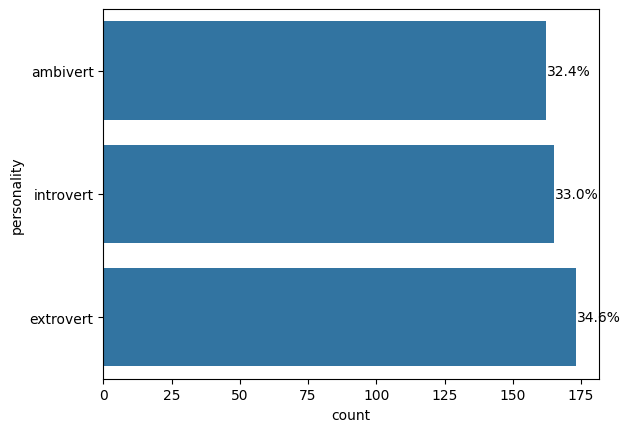

In [39]:
# count plot (i.e. Personality Column)
ax = sns.countplot(y='personality', data=students)

# Total number of students
total = len(students)

# Add percentage labels along the x-axis
for p in ax.patches:
    count = p.get_width()            # width = count for horizontal bars
    pct = count / total * 100
    ax.text(
        count + 0.5,                 # x-position: slightly after the end of bar
        p.get_y() + p.get_height()/2, # y-position: center of the bar
        f'{pct:.1f}%',               # label
        va='center'                  # vertical alignment
    )

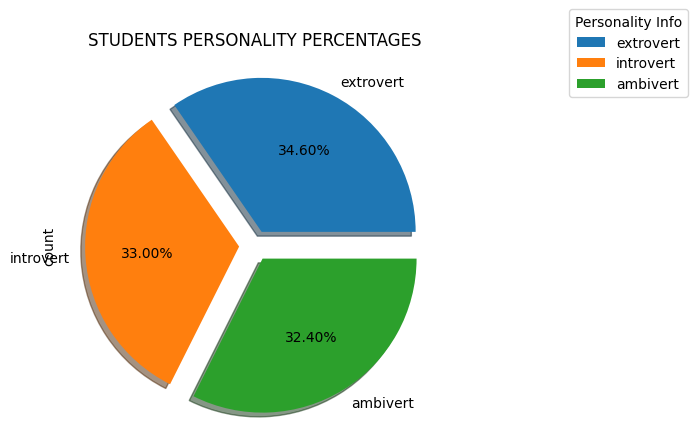

In [83]:
# figure size
plt.figure(figsize = (12, 5)) # Adjust the figure size to visually represent the pie chart 
myexplode = [0.1, 0.1, 0.1]
# pie chart
students['personality'].value_counts().plot(kind = 'pie', autopct = '%.2f%%', explode = myexplode, shadow = True) # plot the pie chart on course column 
# title
plt.title("STUDENTS PERSONALITY PERCENTAGES")
# legend
plt.legend(loc = 'center left', title = 'Personality Info', bbox_to_anchor = (1.3, 1)) # used to add a list of explanation for each wedge
# show plot
plt.show()

<Axes: ylabel='gpa'>

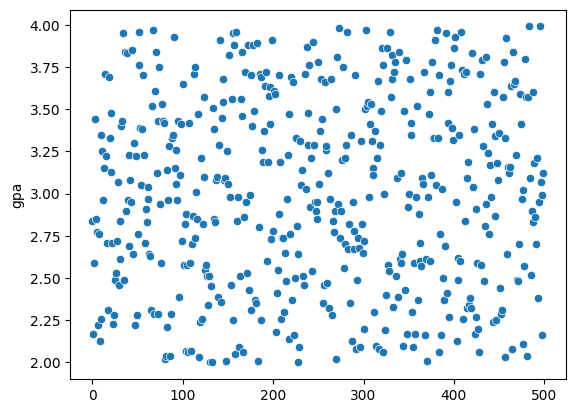

In [41]:
sns.scatterplot(students['gpa'])

AttributeError: Rectangle.set() got an unexpected keyword argument 'kde'

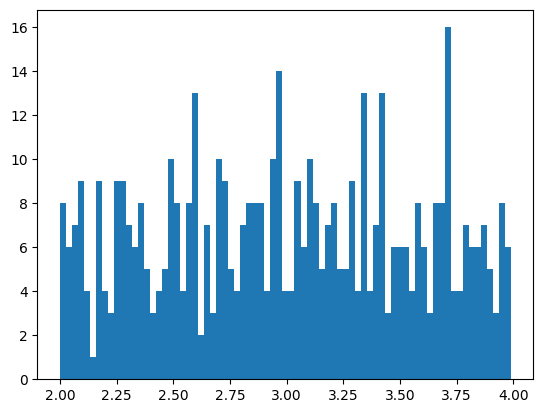

In [84]:
plt.hist(students['gpa'], bins = 75, kde = True)
plt.show()

# **Bivariate and Multivariate Analysis**

It is used to visualize and analyze the relationship between two columns.

C:\Users\Home\AppData\Local\Temp\ipykernel_22396\2576286671.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


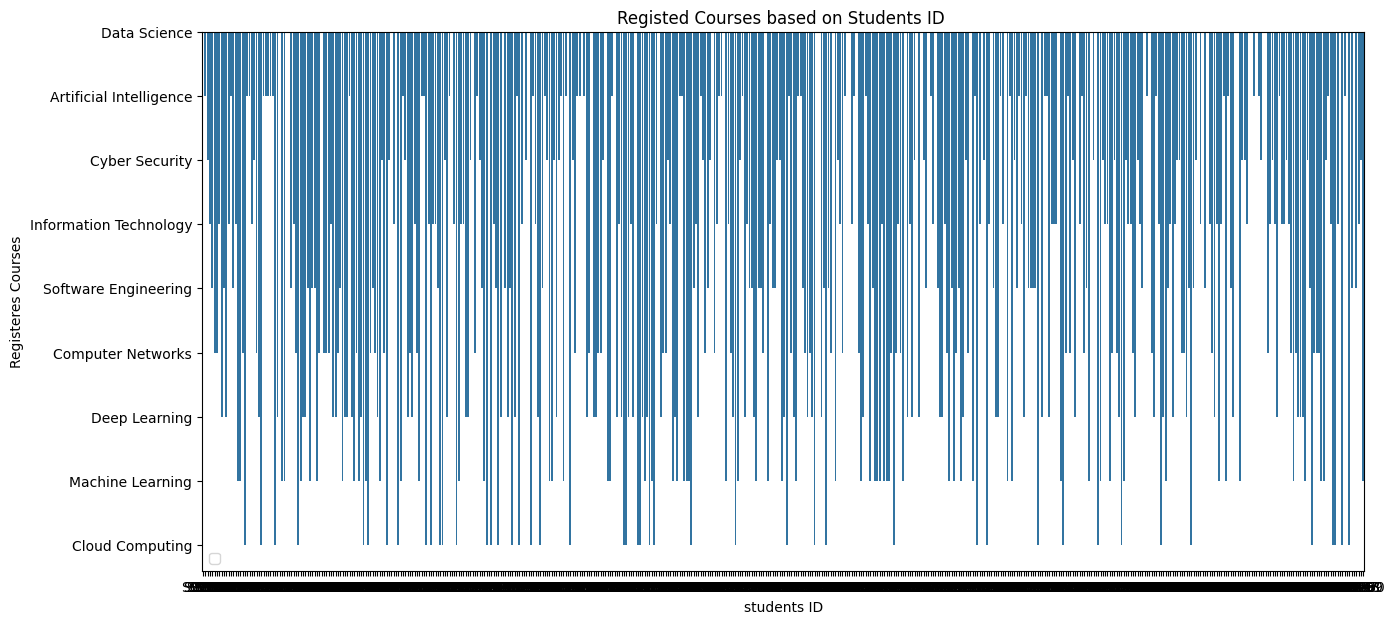

In [43]:
plt.figure(figsize=(15, 7))
sns.barplot(x = students['student_id'], y = students['course'], data = students)
plt.xlabel('students ID')
plt.ylabel('Registeres Courses')
plt.title('Registed Courses based on Students ID ')
plt.legend()
plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_22396\1354331043.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


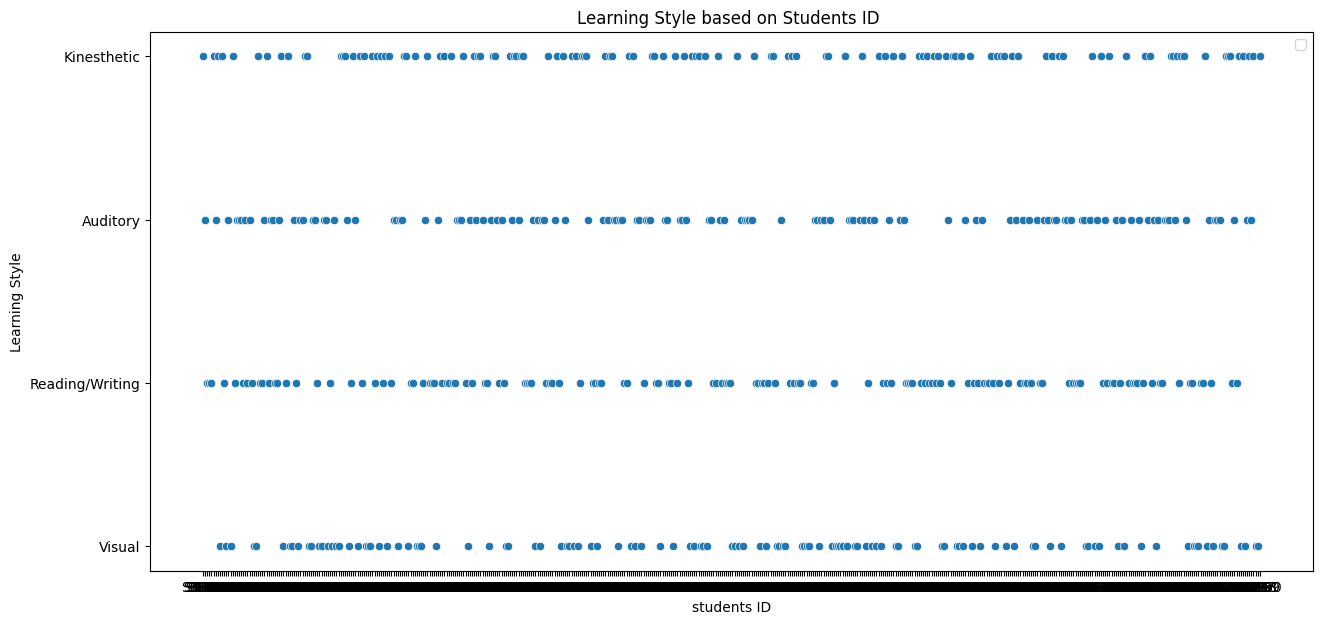

In [44]:
plt.figure(figsize=(15, 7))
sns.scatterplot(x = students['student_id'], y = students['learning_style'])
plt.xlabel('students ID')
plt.ylabel('Learning Style')
plt.title('Learning Style based on Students ID ')
plt.legend()
plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_22396\512127877.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


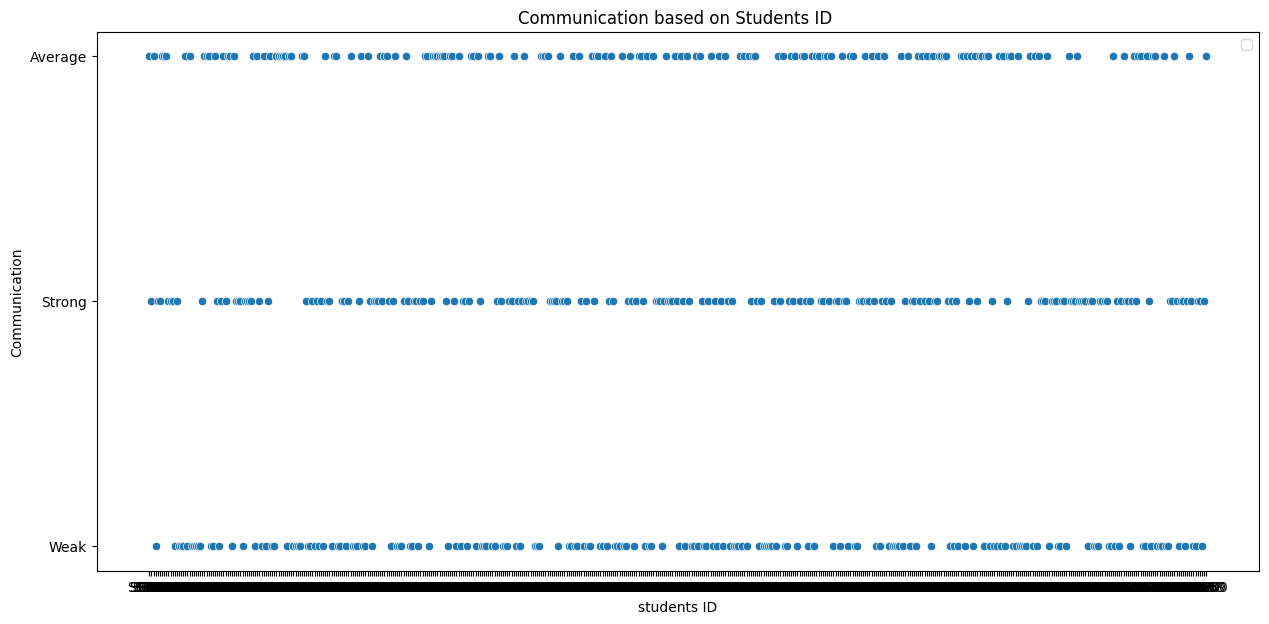

In [45]:
plt.figure(figsize=(15, 7))
sns.scatterplot(x = students['student_id'], y = students['communication'])
plt.xlabel('students ID')
plt.ylabel('Communication')
plt.title('Communication based on Students ID ')
plt.legend()
plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_22396\4069457322.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


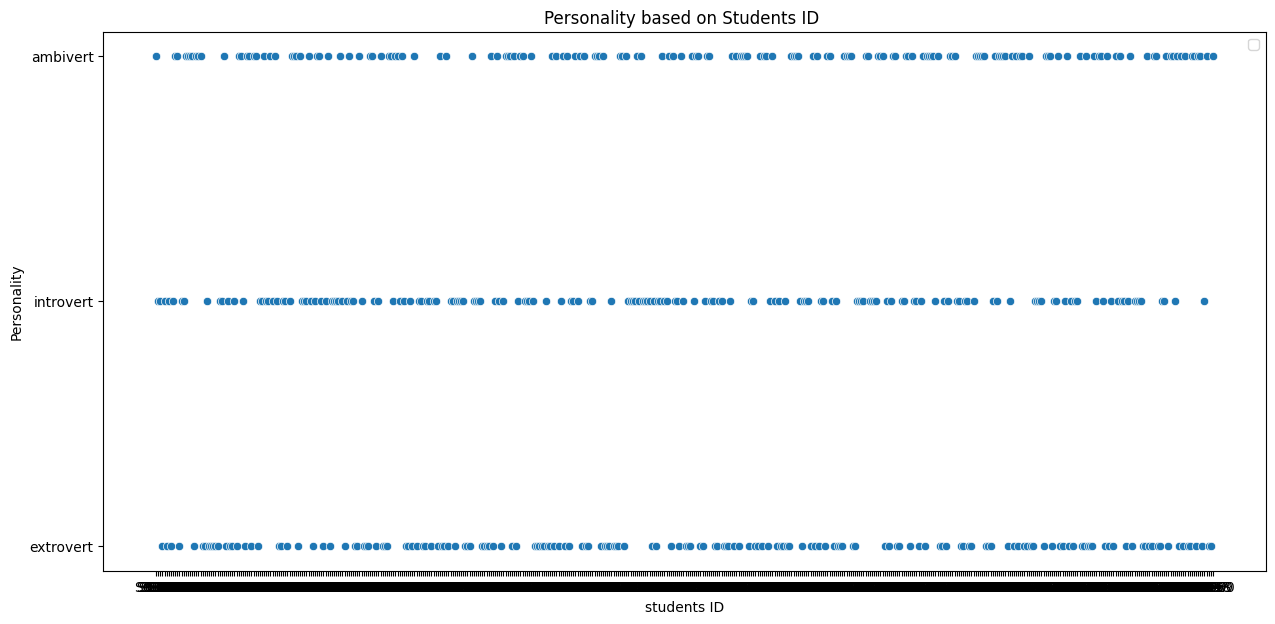

In [46]:
plt.figure(figsize=(15, 7))
sns.scatterplot(x = students['student_id'], y = students['personality'])
plt.xlabel('students ID')
plt.ylabel('Personality')
plt.title('Personality based on Students ID ')
plt.legend()
plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_22396\114930061.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


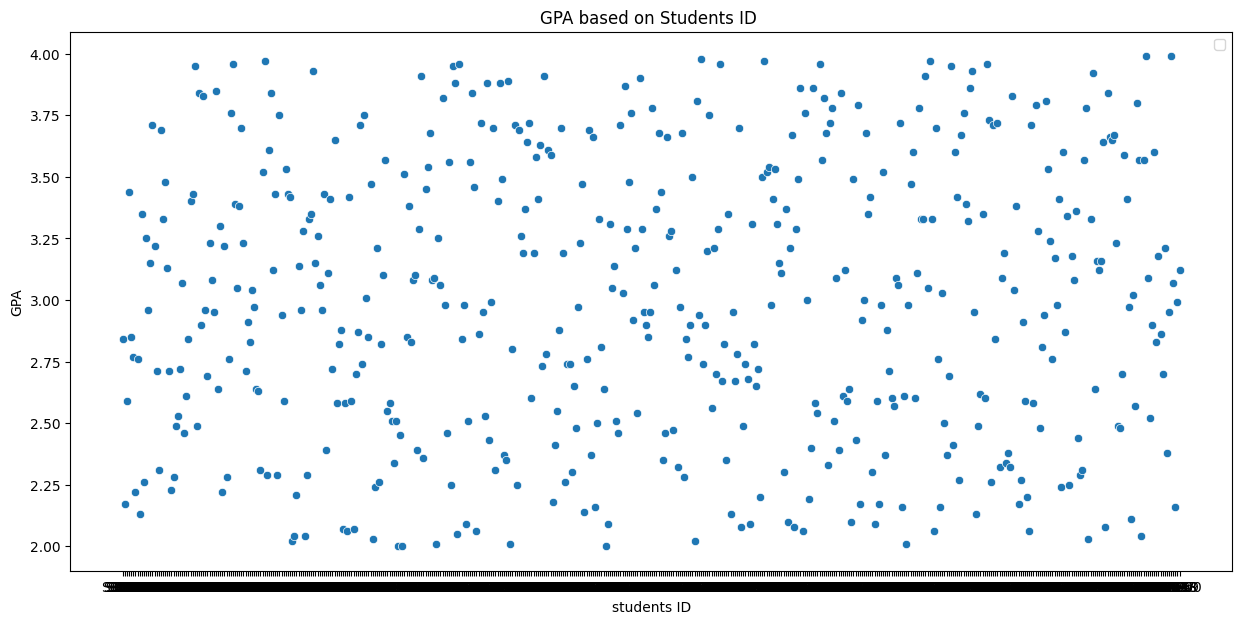

In [47]:
plt.figure(figsize=(15, 7))
sns.scatterplot(x = students['student_id'], y = students['gpa'], data = students)
plt.xlabel('students ID')
plt.ylabel('GPA')
plt.title('GPA based on Students ID ')
plt.legend()
plt.show()